# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 55     |  |
| :-------------|:-------------|
| Floor van de Schaft | Student Studienummer 1 |
| Matthijs van Oostrum | 6540546 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

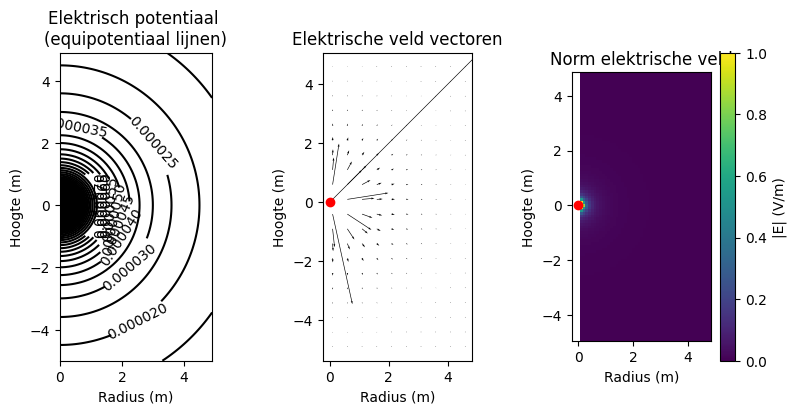

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


index_z0 = np.argmin(np.abs(z))
print(f"1. De index die correspondeert met z = 0m is: {index_z0}")

r_data = r[1:] 
V_data = V[index_z0, 1:]

log_r = np.log10(r_data)
log_V = np.log10(V_data)

def f(x, a, b):
    return a * x + b


popt, pcov = curve_fit(f, log_r, log_V)
exponent_n, constante_b = popt


plt.figure(figsize=(10, 6))
plt.scatter(log_r, log_V, label='Simulatie Data', color='blue', alpha=0.6)
plt.plot(log_r, f(log_r, *popt), color='red', 
         label=f'Curve Fit: $n$ = {exponent_n:.4f}')
plt.xlabel('$\log_{10}(r)$')
plt.ylabel('$\log_{10}(V)$')
plt.legend()
plt.show()


print(f"De berekende exponent (n) is: {exponent_n:.6f}")
print(f"De theoretische waarde is:    -1.00")

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
C:\Users\matth\AppData\Local\Temp\ipykernel_468\2702832420.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(r)$')
C:\Users\matth\AppData\Local\Temp\ipykernel_468\2702832420.py:28: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(V)$')


##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


r_data = r[1:] 
V_data = V[index_z0, 1:]

log_r = np.log10(r_data)
log_V = np.log10(V_data)

def f(x, a, b):
    return a * x + b


popt, pcov = curve_fit(f, log_r, log_V)
exponent_n, constante_b = popt


plt.figure(figsize=(10, 6))
plt.scatter(log_r, log_V, label='Simulatie Data', color='blue', alpha=0.6)
plt.plot(log_r, f(log_r, *popt), color='red',  label=f'Curve Fit: $n$ = {exponent_n:.4f}')
plt.xlabel('$\log_{10}(r)$')
plt.ylabel('$\log_{10}(V)$')
plt.legend()
plt.show()


print(f"De berekende exponent (n) is: {exponent_n:.6f}")
print(f"De theoretische waarde is:    -1.00")

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [ ]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1 # (m)
z_coord_DISK = 0 # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

In [ ]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0 # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius die in de bovenste twee codecellen staat beschreven geeft aan hoe groot de radius van de disk is. Op zich logisch, maar als de radius van de disk nadert naar nul zal het zich meer gaan gedragen als een puntlading. 

2. Als je de diskstep verandert zie dat hoe groter de gridstep des te kleiner het aantal berekende ladingen op de disk. Hoe kleiner de diskstep des te groter het aantal deeltjes op de disk. De gridstep is dus als het ware de dichtheid van de berekeningen van de kracht op de disk. Elk puntje representeerd de lading op dat punt van de disk en de grootte van de gridstep bepaald hoe veel er van die puntjes zijn.(Er staat ook in de eerste cel "inter_charge_distance = gridstep")

3. Ik heb de z-coordinaten van zowel de eerste als de tweede codecel verandert. Echter verandert de positie van de disk niet. (Waarschijnlijk is het ergens gehardcode ofzo??) Maar dit zou de simulatie waarschijnlijk ook niet veranderen. Dit zou slechts de hoogte van de disk veranderen op de z-as. 

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [ ]:
###
###Hier jouw code###
import numpy as np

totale_lading = number_point_charges_on_disk * charge_one_point
oppervlakte = np.pi * (disk_radius ** 2)
sigma = totale_lading / oppervlakte

# 4. Print het resultaat
print(f"De ladingsdichtheid sigma is: {sigma:.4e} C/m^2")


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

In [ ]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.argmin(np.abs(z))

V_0 = (sigma * disk_radius) / (2 * epsilon0) # potentiaal op r = 0
print(sigma )
V_R = (sigma * disk_radius) / (np.pi * epsilon0) # potentiaal op de straal van de schijf
r_R = disk_radius  # straal van de schijf

plt.title(f"Potentiaal in een schijf met straal {disk_radius} m")
plt.plot(r, V[idx_z_zero, :], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", markersize=12, label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", markersize=12, label="theoretisch potentiaal $r$=R m")
plt.legend()
plt.xlabel("r  in $m$")
plt.ylabel("Potentiaal in $V$")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


In [ ]:
# Zoek de index waar r (ongeveer) 0 is
idx_r_zero = np.argmin(np.abs(r))

# 1. Numeriek berekend potentiaal op de z-as (alle z-waarden, maar r=0)
V_numeriek_z = V[:, idx_r_zero] 

# 2. Theoretisch potentiaal
V_theoretisch_z = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

# Plotten
plt.figure(figsize=(8, 5))
plt.plot(z, V_numeriek_z, label="Numeriek potentiaal (r=0)")
plt.plot(z, V_theoretisch_z, '--', label="Theoretisch potentiaal ($R \gg z$)")
plt.xlabel("z-as (m)")
plt.ylabel("Potentiaal (V)")
plt.title("Elektrisch Potentiaal op de z-as van een geladen schijf")
plt.legend()

# 3. Sla de plot op
plt.savefig("plot_2d.png")
plt.show()


#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

In [ ]:
# 1. Zoek de index voor r=0, maar nu in de speciale r_for_E array
idx_r_zero_E = np.argmin(np.abs(r_for_E))


Ez_numeriek_z = Ez[:, idx_r_zero_E]

# 2. Theoretisch elektrisch veld
E_theoretisch_z = (sigma / (2 * epsilon0)) * np.sign(z_for_E)

# Plotten 
plt.figure(figsize=(8, 5))
plt.plot(z_for_E, Ez_numeriek_z, label=r"Numeriek berekend $E_z$ (r=0)")
plt.plot(z_for_E, E_theoretisch_z, '--', label=r"Theoretisch $E_z$ (oneindige plaat)")
plt.xlabel("z-as (m)")
plt.ylabel("Elektrisch veld $E_z$ (V/m)")
plt.title("Z-component van het elektrische veld op de z-as")
plt.legend()

# 3. Sla de plot op
plt.savefig("plot_2e.png")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f



**Antwoorden 2f**

**1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?**

Het elektrische veld wordt benaderd als een oneindig geladen plaat als de loodrechte component vele male groter is dan de straal van de schijf. Je zit als het ware zo dicht op de schijf dat de straal "oneindig ver" reikt. De invloed van de randen van de schijf is dus verwaarloosbaar klein waardoor de schijf als het ware oneindig is. 


**2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.**

Dichtbij de oorsprong vallen de berekende en theoretische waarde vrijwel samen, maar zodra de afstand afneemt niet meer. De stippellijn representeerd de theoretische veldsterkte van een oneindige plaat, echter heeft de berekende schijf geen oneindige straal. Daarom begint de berekende waarde steeds verder af te wijken hoe verder je beweegt van z=0. Op grotere afstanden gedraagt de schijf zich steeds meer als puntlading, waardoor de veldsterkte exponentieel afneemt


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

In [ ]:
from IPython.display import Image, display

# Voeg de opgeslagen figuren hieronder toe
print("Plot voor het potentiaal (Vraag 2d)")
display(Image("plot_2d.png"))

print("Plot voor het elektrisch veld (Vraag 2e)")
display(Image("plot_2e.png"))

##### Antwoorden 2g

Als de straal van de schijf op 3 wordt gezet, is er een redelijke overeenkomst met de theoretische waardes die worden weergeven door de oranje lijn. Zodra de straal groter wordt gemaakt, zal de numerieke berekening de theoretische waarde veel nauwer volgen (zoals ook te zien is als je de straal aanpast). 

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

**Antwoord 2h:**

We stellen als eis dat het veld van de schijf ($E_{\text{schijf}}$) gelijk is aan 10% van het veld van een oneindige plaat ($E_{\text{plaat}}$):

$$E_{\text{schijf}} = 0.10 \times E_{\text{plaat}}$$

Vul de bekende formules voor beide velden in (zoals gegeven in de theorie):

$$\frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right] = 0.10 \times \frac{\sigma}{2\epsilon_0}$$

We kunnen nu aan beide kanten de term $\frac{\sigma}{2\epsilon_0}$ wegstrepen:

$$1 - \frac{z}{\sqrt{R^2 + z^2}} = 0.10$$

Nu gaan we de vergelijking omschrijven om $z$ vrij te maken. Eerst halen we de breuk naar de andere kant:

$$\frac{z}{\sqrt{R^2 + z^2}} = 1 - 0.10$$

$$\frac{z}{\sqrt{R^2 + z^2}} = 0.90$$

Om de wortel weg te werken, kwadrateren we beide kanten:

$$\frac{z^2}{R^2 + z^2} = 0.81$$

Vermenigvuldig nu beide kanten met de noemer ($R^2 + z^2$):

$$z^2 = 0.81(R^2 + z^2)$$

Haakjes wegwerken:

$$z^2 = 0.81R^2 + 0.81z^2$$

Haal alle termen met $z$ naar de linkerkant door $0.81z^2$ af te trekken van $1z^2$:

$$0.19z^2 = 0.81R^2$$

Deel beide kanten door $0.19$:

$$z^2 = \frac{0.81}{0.19} R^2$$

$$z^2 = \frac{81}{19} R^2$$

Neem ten slotte de wortel aan beide kanten om de exacte hoogte $z$ te vinden:

$$z = \sqrt{\frac{81}{19}} R = \frac{9}{\sqrt{19}} R$$

*(Dit betekent dat op een hoogte van $z \approx 2.06 R$ het veld is afgenomen tot 10% van de waarde van een oneindige plaat).*

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

In [ ]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def get_r_axis(r_like):
    """
    Geef de 1D r-as terug. 
    - Als r_like 2D meshgrid is: neem de kolomas r (eerste rij).
    - Als r_like 1D is: geef direct terug.
    """
    if r_like.ndim == 2:
        # Bij meshgrid('xy') varieert r langs de kolommen
        return r_like[0, :]
    return r_like  # 1D

def get_z_axis(z_like):
    """
    Geef de 1D z-as terug.
    - Als z_like 2D meshgrid is: neem de rij-as z (eerste kolom).
    - Als z_like 1D is: geef direct terug.
    """
    if z_like.ndim == 2:
        return z_like[:, 0]
    return z_like  # 1D


r_axis = get_r_axis(r_for_E)   
z_axis = get_z_axis(z_for_E)     

# Kolomindex die het dichtst bij r = 0 ligt
idx_r0 = int(np.argmin(np.abs(r_axis - 0.0)))


Ez_line = Ez[:, idx_r0]
normE_line = normE[:, idx_r0]

#plotten
plt.figure(figsize=(6, 4))
plt.plot(z_axis, Ez_line, label="Ez langs r = 0")
plt.axvline(0, color='k', lw=0.8, alpha=0.4)  # referentie bij z=0
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("Elektrische veldcomponent Ez op de as van de schijf (r = 0)")
plt.grid(True, ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

#Dit heeft chatgpt geschreven ik snapte niet wat er fout ging
pos_indices = np.where(z_axis > 0)[0]
if pos_indices.size > 0:
    idx_near_center = pos_indices[0]
else:
    
    idx_near_center = int(np.argmin(np.abs(z_axis - 0.0)))

E_center_value = float(normE_line[idx_near_center])
print(f"Norm van het elektrische veld vlak boven het centrum (r=0, z≈{z_axis[idx_near_center]:.3e} m): {E_center_value:.3f} V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

Om de oppervlaktelading te benaderen, gebruiken we de randvoorwaarden van het elektrische veld bij een geleider (de Wet van Gauss).
 Vlak boven het midden van de schijf is de relatie tussen de oppervlaktelading $\sigma$ en het elektrische veld $E_z$:$\sigma = 2 \epsilon_0 E_z$Omdat we het elektrische veld kunnen benaderen met de afgeleide van het potentiaal ($E_z \approx -\frac{\Delta V}{\Delta z}$), luidt de formule voor de numerieke benadering:$\sigma \approx -2 \epsilon_0 \frac{V(0, z + \Delta z) - V(0, z)}{\Delta z}$(waarbij $\Delta z$ je grid_step is, $V(0,z)$ het potentiaal op de schijf is, en $V(0, z+\Delta z)$ het potentiaal nét een roosterpunt boven de schijf).

In [ ]:
import numpy as np
from scipy.constants import epsilon_0


idx_r_zero = np.argmin(np.abs(r))

#positie van de schijf
idx_z_disk = np.argmin(np.abs(z - z_coord_DISK))

#potentiaal op en net boven de schijf
if V.shape[0] == len(r):
    # V is opgebouwd als V[r, z]
    V_op_schijf = V[idx_r_zero, idx_z_disk]
    V_net_boven = V[idx_r_zero, idx_z_disk + 1]
else:
    # V is opgebouwd als V[z, r]
    V_op_schijf = V[idx_z_disk, idx_r_zero]
    V_net_boven = V[idx_z_disk + 1, idx_r_zero]

#Berekenen elektrische veld
E_z_midden = - (V_net_boven - V_op_schijf) / grid_step

#Berekenen van de benadering van de oppervlaktelading
sigma_midden_benadering = 2 * epsilon_0 * E_z_midden

#resultaten
print(f"Benaderde oppervlaktelading in het midden (r=0): {sigma_midden_benadering:.4e} C/m^2")

#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Bepaal de totale lading Q met de waarde uit 3b
# We gaan er hier vanuit dat de variabele uit 3b 'sigma_midden_benadering' heet
Q = sigma_midden_benadering * 2 * np.pi * (disk_radius**2)

# 2. Bepaal de sigma voor een uniforme schijf met dezelfde lading Q
sigma_uniform = Q / (np.pi * (disk_radius**2))

# Print de vergelijking netjes uit
print(f"Totale berekende lading Q op de schijf: {Q:.4e} C")
print(f"Sigma in centrum geleidende schijf:     {sigma_midden_benadering:.4e} C/m^2")
print(f"Sigma van uniforme schijf (zelfde Q):   {sigma_uniform:.4e} C/m^2")
print("\nConclusie: De oppervlaktelading in het centrum van de geleider is")
print("precies de helft van de lading op een uniform geladen schijf!")

# 3 & 4. --- PLOTTEN ---
# We maken een array voor r die loopt van 0 tot 99% van de radius. 
# Dit voorkomt een "Division by zero" error op exact r = R.
r_plot = np.linspace(0, disk_radius * 0.99, 200)

# Bereken sigma(r) voor de geleider met de gegeven formule
sigma_geleidend = Q / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_plot**2))

plt.figure(figsize=(8, 5))
plt.title("Oppervlakteladingsdichtheid van een schijf")

# Plot de geleidende schijf
plt.plot(r_plot, sigma_geleidend, "b-", linewidth=2, label="Geleidende schijf $\sigma(r)$")

# Plot de uniforme schijf (dit is een rechte horizontale lijn over de hele straal)
plt.plot([0, disk_radius], [sigma_uniform, sigma_uniform], "r--", linewidth=2, label="Uniform geladen schijf $\sigma_{uniform}$")

plt.legend()
plt.xlabel("Radiale afstand $r$ (m)")
plt.ylabel("Oppervlaktelading $\sigma$ (C/m$^2$)")
plt.grid(True)
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [ ]:
#***hier jouw code*** 

#maximum veld
max_E = np.max(normE)

# 2. Bepaal de locatie
idx_max = np.unravel_index(np.argmax(normE), normE.shape)

#Dimensie check
if normE.shape[0] == len(r_for_E):
    idx_r, idx_z = idx_max[0], idx_max[1]
else:
    idx_z, idx_r = idx_max[0], idx_max[1]

r_max = r_for_E[idx_r]
z_max = z_for_E[idx_z]

#absolute waarde van het veld uit 3b
E_midden_mag = np.abs(E_z_midden) 

#Bereken de verhouding
verhouding = max_E / E_midden_mag
verschil = max_E - E_midden_mag

#resultaten
print("--- Resultaten Edge Effect ---")
print(f"Maximum elektrisch veld: {max_E:.4e} V/m")
print(f"Locatie van maximum:     r = {r_max:.4f} m, z = {z_max:.4f} m")
print(f"E-veld in het centrum:   {E_midden_mag:.4e} V/m")
print(f"-> Het maximum is {verhouding:.1f} keer zo hoog (een toename van {verschil:.4e} V/m).")

##### Antwoord 3d.5

*Schrijf hier je argumentatie voor vraag 3d.5.*

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

In [ ]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


In [ ]:
#De as van de schijven is bij r = 0
#Boven platen waaieren lijnen uit, niet constant dus. Veldlijnen spreiden uit worden zwak Ez - > 0
#Ez hoe snel verandert potentiaal als je naar boven gaat
#De twee schijven gedragen zich als een platte condensator


# zorgen voor 1D waarden voor de r-as
if r_for_E.ndim == 2:
    r_axis = r_for_E[0, :]
else:
    r_axis = r_for_E

# zorgen voor 1D waarden voor de z-as
if z_for_E.ndim == 2:
    z_axis = z_for_E[:, 0]
else:
    z_axis = z_for_E

#r-axis alle r-posities in je grid, we zoeken r = 0.0 m of r = ong. 0.0 m
#argmin zoekt de index die het kleinst is van (r_axis - 0.0)

positie_r0 = np.argmin(np.abs(r_axis - 0.0))
print(positie_r0)

#nu definieren we Ez
Ez_lijn = Ez[:, positie_r0]

#nu plotten we Ex tegenover de z-as om het gedrag van het elektrisch veld op de as van de schijven weer te geven


plt.figure(figsize=(6, 4))
plt.plot(z_axis, Ez_lijn, label='Ez langs de as (r = 0)')
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("Z-component van het elektrische veld tussen twee platen")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

*Antwoorden 4b*

*Antwoord 4b.1*

Zie een schematische weergave van het elektrisch veld tussen de twee geleidende platen in de cel hieronder.

Tussen de platen ($-1 < z < 1$) trekken de positieve en negatieve plaat elkaar aan. De veldlijnen lopen van plus naar min en is het elektrisch veld is daardoor vrijwel constant en gelijk aan $E_z$ = -10 $V/m$. Dit volgt uit de volgende benadering van het elektrisch veld tussen twee oneindige platen:

$E_z = -\frac{V_1 - V_2}{d}$

Invullen geeft:

$E_z = -10,\text{V/m}$

Het minteken betekent dat het veld gericht is van de positieve naar de negatieve plaat (naar beneden).

Buiten de platen ($z > 1$ en $z < -1$) werken de velden elkaar tegen en geldt:

$E_z \approx 0$ (de velden heffn elkaar op en worden nagenoeg nul)



*Antwoord 4b.2*

Het numeriek berekende elektrische veld op de as van de schijven ($r = 0$) vertoont precies het gedrag dat theoretisch verwacht wordt voor twee geleidende platen. Het model geeft ook een constante waarde aan in het gebied $-1 < z < 1$ van $E_z \approx -10,\text{V/m}$. Verder tussen de platen ($z > 1$ en $z < -1$) neemt het veld snel af tot ongeveer nul:

$E_z \approx 0$,


*Antwoord 4b.3*

Voor een enkele geleidende schijf is het elektrisch veld juist zwak in het centrum, waar $r$ = 0 en $z$ = 0. In dat geval wordt het veld pas sterk naar de randen toe. Het veld van één schijf is dus niet uniform, de sterkte is niet overal constant en afhankelijk van positie. 

Tussen twee platen ontstaat wél een sterk en overal even groot elektrisch veld, terwijl één schijf een zwak en ongelijk veld geeft dat alleen bij de rand sterk wordt; daarom is de tweeschijvenopstelling veel beter als je een uniform veld nodig hebt.

![Foto voor de opdracht:P ](Foto-onlineopdracht1-4f.jpeg)

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [ ]:
#vraag 4c.1
#verwachte oppervlaktelading op de binnenzijde van een van de schijven
#relatie tussen de twee geleiders is ->  sigma = epsilon0 * velsterkte

#uit 4a. en 4b. volgt dat het veld tussen de twee platen ongeveer gelijk is aan -10V/m

E_z = -10 #V/m

epsilon0 = 8.854187817e-12  # F/m
sigma = epsilon0 * E_z  # C/m^2

#4c.2
#de verwachte totale lading op beide schijven
#totale lading op één schijf

A = np.pi * disk_radius**2   # oppervlak
Q = sigma * A                # totale lading

Q_totaal = 2 * abs(Q)       # totale |lading| op beide platen


#4c.3 
#de capiciteit van de situatie, met de capiciteit gedefinieerd als Q (lading op één plaat) / V (spanningsverschil tussen de platen)

V = 20  # spanning tussen beide platen -> (10 - (-10)) = 20 V

C = abs(Q) / V  #capciteit is postitief

#4c.4 

print(f"Oppervlaktelading σ = {sigma:.1e} C/m^2")
print(f"Lading op één plaat = {Q:.1e} C")
print(f"Totale lading op beide platen = {Q_totaal:.1e} C")
print(f"Capaciteit = {C:.1e} F")

#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

*4d.1 antwoord*

Ja, de oppervlaktelading aan de buitenkant is in het ideale geval nagenoeg nul. Buiten de twee (oneindig grote) schijven heffen de elektrische velden van de positieve en negatieve plaat elkaar op. Het veld van de ene plaat is even groot, maar tegengesteld gericht aan het veld van de andere plaat. Daardoor is het resulterende elektrische veld buiten de platen nul.

Voor een geleider geldt dat het elektrisch veld net buiten het oppervlak gerelateerd is aan de oppervlakteladingsdichtheid via:

$E$ = $𝜎/𝜀0$

Als het elektrisch veld buiten nul is, volgt hieruit dat de oppervlakteladingsdichtheid σ daar ook nul moet zijn.

*4d.2 antwoord*

Ladingen in een geleider schuiven net zo lang totdat binnenin geen veld meer is en aan het oppervlak van de geleider zit dan precies genoeg lading om het externe veld te kunnen maken die gaat lopen. Daarom komt alle netto lading op het oppervlak van de geleider terecht. Deze oppervlaktelading zorgt precies voor het elektrische veld dat net buiten de geleider aanwezig is.

Het elektrisch veld vlak buiten het oppervlak van de geleider staat loodrecht op dat oppervlak en is gelijk aan $E$ = $𝜎/𝜀0$.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [ ]:
#4e
#wat is de waarde van het z-component rond r = 0

positie_r0 = np.argmin(np.abs(r_axis - 0.0))

#z-axis alle z-posities en z_pos_disk1 is de z-hoogte van de onderste schijf
#we zoeken eerst de index van z die het dichts bij de plaat zit

positie_z_dichtst = np.argmin(np.abs(z_axis - z_pos_disk1))

#dit geeft de index van het z-component waar de afstand tot de schijfhoogte, dus de onderste schijf, het kleinst is
#hieronder zoeken we twee gridpunten net boven én net onder de plaat

positie_onder = positie_z_dichtst - 1
positie_boven = positie_z_dichtst + 1

#de bijpassende arrays bij de posities (de z-component op r = 0)

Ez_below = Ez[positie_onder, positie_r0]   # net onder de onderste plaat
Ez_above = Ez[positie_boven, positie_r0]   # net boven de onderste plaat

#met de omgeschreven formule uit 4d. 2 (E = 𝜎/𝜀0) wordt de ladingsdichtheid berekend

sigma_bottom = epsilon0 * Ez_below    # ladingsdichtheid onderkant onderste plaat
sigma_top    = epsilon0 * Ez_above    # ladingsdichtheid bovenkant onderste plaat


print(" Vraag 4e: Numeriek berekende ladingsdichtheid ")
print(f"1. Ez net onder de onderste plaat:    {Ez_below:.3e} V/m")
print(f"2. σ onderkant onderste plaat:       {sigma_bottom:.3e} C/m²")
print(f"3. Ez net boven de onderste plaat:    {Ez_above:.3e} V/m")
print(f"4. σ bovenkant onderste plaat:       {sigma_top:.3e} C/m²")

#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

In vraag 4c gebruikte je de ideale formule voor de twee geleidende platen, die ervan uitgaat dat de platen oneindig groot zijn en dat het elektrisch veld perfect constant is. In dat ideale model zit overal dezelfde ladingsdichtheid σ op het oppervlak. Maar in vraag 4d en 4e zie je dat dit in een werkelijke (numeriek berkende) situatie niet precies zo is. De onderkant van de onderste plaat heeft een negatieve ladingsdichtheid en de bovenkant heeft een positieve ladingsdichtheid. De lading verdeelt zich dus niet uniform over de schijf en er zit lading op beide zijden van de plaat.


*4f.2 antwoord*

Gezien de lading zich niet uniform verdeelt en er lading zit op beide kanten van de plaat, is de lading van het veld tussen de platen minder sterk. In 4c wordt de capaciteit berekend zonder hier rekening mee te houden en overschat de capaciteit uit 4c de werkelijke capaciteit van de eindige schijven.

*4f.3 antwoord*

Door het verklleinen van de afstand tussen de platen wordt het elektrisch veld sterker en de oppervlaktelading concentreert zich meer op de naar elkaar gerichte zijden van de platen. Het model gaat zich steeds idealer gedragen. Bij een kleinere afstand wordt de verdeling van de lading uniformer aan de binnenkanten, het veld wordt sterker en de effectieve capaciteit stijgt richting de ideale waarde.



### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [ ]:
#epsilon_r is relatieve permittiviteit van een materiaal (standaard 1 voor een vacuum)


def vlakkeplaat(A, d, epsilon_r = 1): #de relatieve permittiviteit bij lucht of vacuum mag deze gelijkgesteld worden aan 1
    epsilon_0 = 8.854e-12  # permittiviteit van vacuum in F/m
    C = epsilon_0 * epsilon_r * A / d
    return C

#voor een cilinder kijken we naar de ruimte waar het elektrisch veld tussen de cilinder zit. Deze afstand, tussen de binnen en de buitenwand is vergelijkbaar met de afstand tussen de platen in eeen vlakke plaat condensator die bepaalt hoe sterk het veld is.

def cilinder(r1, r2, L, epsilon_r = 1):
    epsilon_0 = 8.854e-12  
    epsilon = epsilon_0 * epsilon_r
    d = r2 - r1     # afstand tussen binnen- en buitenwand
    C = 2 * np.pi * epsilon * (L * r1) / d
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [ ]:
#5b.1
# 1. vlakkenplaat
A_plaat = 0.10 * 0.10       # oppervlakte (m)
d_plaat = 0.001             # diamter (m)

#met lucht als medium mag epsilon_r = 1 worden aangenomen

Cb1_vlakkenplaat = vlakkeplaat(A_plaat, d_plaat, epsilon_r=1)

#5b.2
# 2. Cilinder
r1_cil = 0.009 / 2          # binnendiameter (m)
r2_cil = 0.010 / 2          # buitendiameter (m)
L_cil = 0.10                # lengte (m)

Cb2_cilinder = cilinder(r1_cil, r2_cil, L_cil, epsilon_r=1)

#5b.3
Cap_dubbel_vlak = vlakkeplaat(A_plaat, 2*d_plaat, epsilon_r=1)

def cilinder_dubbel(r1, r2, L, epsilon_r = 1):
    epsilon_0 = 8.854e-12  
    epsilon = epsilon_0 * epsilon_r
    d = r2 - r1     # afstand tussen binnen- en buitenwand
    C = 2 * math.pi * epsilon * (L * r1) / 2*d
    return C

Cap_dubbel_cil = cilinder(r1_cil, r2_cil, L_cil, epsilon_r=1)  

#5b.4
#als de condensatoren gevuld zijn met water is de epsilon_r = 80

Cap_water_vlak = vlakkeplaat(A_plaat, d_plaat, epsilon_r=80)
Cap_water_cil = cilinder(r1_cil, r2_cil, L_cil, epsilon_r=80)

#5b.5 
#als de condensatoren gevuld zijn met PVC is de espilon_r = 3

Cap_PVC_vlak = vlakkeplaat(A_plaat, d_plaat, epsilon_r=3)
Cap_PVC_cil = cilinder(r1_cil, r2_cil, L_cil, epsilon_r=3)

#antwoorde geprint
print(f"1) Vlakke plaat, lucht: {Cb1_vlakkenplaat:.2e} F")
print(f"   Cilinder, lucht: {Cb2_cilinder:.2e} F\n")

print(f"2) Vlakke plaat, lucht, afstand verdubbeld: {Cap_dubbel_vlak:.2e} F")
print(f"   Cilinder, lucht, afstand verdubbeld: {Cap_dubbel_cil:.2e} F\n")

print(f"3) Vlakke plaat, water: {Cap_water_vlak:.2e} F")
print(f"   Cilinder, water: {Cap_water_cil:.2e} F\n")

print(f"4) Vlakke plaat, PVC: {Cap_PVC_vlak:.2e} F")
print(f"   Cilinder, PVC: {Cap_PVC_cil:.2e} F")

#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [ ]:
#5c.1

cap_cil = 1e-6         # capiciteit (1 microF)
r1 = 0.005 / 2         # binnenstraal (m)
r2 = 0.006 / 2         # buitenstraal (m)
d = r2 - r1
epsilon_r = 1
epsilon_0 = 8.854e-12
epsilon = epsilon_0 * epsilon_r

# lengte berekenen
L_cil = cap_cil * d / (2 * np.pi * epsilon * r1)
print(f"Cilinder condensator: lengte L = {L_cil:.2f} m")

#5c.2

cap_plaat = 1e-6             # 1 microF
b = 0.006                    # breedte (m) = 6 mm
d_plaat = 0.0005             # afstand (m) = 0.5 mm

epsilon_r = 1                            # lucht
epsilon_plaat = epsilon_0 * epsilon_r

# L uitrekenen voor rechthoekige platen (A = b * L)
L_plaat = cap_plaat * d_plaat / (epsilon_plaat * b)
print(f"Vlakke plaat condensator: lengte L = {L_plaat:.3f} m")

#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

*5d.1 antwoord*

Nee de antwoorden uit 5c zijn niet realistisch. De platen in dit model staan veels te ver uit elkaar, waardoor de capiciteit heel klein wordt. Hierdoor zijn de lengtes van de cilinder of vlakke plaat condensator veels te groot en dus niet reëel.

*5d.2 antwoord*

In condensatoren is de afstand tussen de platen vele malen kleiner en gebruiken ze materialen met een veel hogere permitiviteit dan lucht (epsilon_r). Daardoor kan een echte condensator wél een hoge capaciteit hebben zonder heel groot te zijn.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [ ]:
# Gegeven
V = 10_000               # volt
v = 70/3.6               # m/s
epsilon_0 = 8.854e-12
epsilon_r = 80           # water
d = 0.001                # afstand platen (m)


def energie_formule(C, V):
    E = 0.5 * C * V**2
    return E


#5e.1
#schat de massa van een treintje dat afgeschoten wordt

massa_mens = 6*75   #massa van de mensen in het treintje
massa_kar = 300     #grove schatting massa kar

massa_totaal = massa_mens + massa_kar

#5e.2
#totale energie van het treintje na het afschieten

E = 0.5 * massa_totaal * v**2    #kinetische energie

#5e.3
#capaciteit van het treintje

C = 2 * E / V**2

#5e.4
#oppervlakte van vlakke-plaat condensator

A = C * d / (epsilon_0 * epsilon_r)

#5e.5
#alle uitkomsten netjes op een rijtje

print(f"1) Geschatte massa treintje: {massa_totaal:.0f} kg")
print(f"2) Kinetische energie: {E:.2e} J")
print(f"3) Benodigde capaciteit: {C:.3e} F")
print(f"4) Nodig oppervlak bij water en 1 mm afstand: {A:.2f} m")

##### Antwoorden 5e

Condensatoren kunnen een veel hogere capiciteit hebben en nog steeds heel klein zijn door hun opbouw. In plaats van twee losse platen gebruiken ze hele lange strips metaal die strak worden opgerold, hierdoor wordt het contact oppervlak ook veel groter. Ze gebruiken ook speciale materialen die veel beter lading kunnen opslaan dan lucht. Daarnaast zitten de lagen superdicht op elkaar, veel dichter dan je zelf kunt maken. Daardoor past er heel veel energie in een kleine condensator.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

In [ ]:
#5f.1 vlakke plaat condensator

A_plaat_5f = 0.10 * 0.10          # m^2
d_afstand = np.linspace(0.5e-3, 5e-3, 300)   # 0.5 mm tot 5 mm
cap_plaat = vlakkeplaat(A_plaat, d_afstand, epsilon_r=1)   #epsilon_r voor lucht = 1


plt.figure(figsize=(7,5))
plt.plot(d_afstand*1000, cap_plaat)
plt.xlabel("Afstand d (mm)")
plt.ylabel("Capaciteit C (F)")
plt.title("Capaciteit vlakke plaat condensator (lucht)")
plt.grid(True)
plt.tight_layout()
plt.show()

#5f.2 cilinder condensator

r1 = 0.009 / 2
r2 = 0.010 / 2
L0 = 0.10        # beginlengte (m)
T = 10           # tijd (s)

t_interval = np.linspace(0, T, 300)
L_interval = L0 * (1 - t_interval / T)    #afname van de lengte over tijd

cap_cilinder = cilinder(r1, r2, L_interval, epsilon_r=1)

plt.figure(figsize=(7,5))
plt.plot(t_interval, cap_cilinder)
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit C (F)")
plt.title("Capaciteit cilindercondensator tijdens uitdraaien")
plt.grid(True)
plt.tight_layout()
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [ ]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1



#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [ ]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen




##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*1. Leidt het D veld van de condensator af uit de wet van Gauss*

De wet van Gauss voor het elektrisch veld tussen twee platen met een niet-lineair diëlektricum van een condensator is:

$$
\oint \vec{D} \cdot d\vec{A} = Q_{\text{vrij}}
$$

Een spons is een niet-linear diëlektricum. Dit materiaal kan vervormen en verandert daarmee de permittiviteit als gevolg van bijvoorbeeld druk. Een diëlektricum is materiaal dat gepolariseerd wordt door een elektrisch veld.

Door polarisatie dringt het veld anders door het materiaal. Het veld groeit niet linear mee en daarom werkt de lineaire vlakke-plaatformule niet.

Het D-veld uit de wet van Gauss meet hoeveel vrije lading er op de platen staan en is niet afhankelijk van het materiaal. Voor een vlakke-plaat condensator staat het D-veld loodrecht op het oppervlak:

$$
D * A = Q_v 
$$

Met $Q_v$ is de hoeveelheid vrije lading er op de platen staat. Om hieruit het elektrisch veld $E(D)$ te berekenen wordt de materiaalformule voor een niet-lineair diëlektricum gebruikt, waar de polarisatie in wordt meegenomen.

*Verband tussen het D-veld en het Elektrisch veld*

$$
D = \varepsilon_0 E + P
$$

*De polarisatie van een niet-lineair diëlektricum*

$$
P = \varepsilon_0 \left( \chi_1 E + \chi_2 E^2 \right)
$$

*Ofwel*

$$
D = \varepsilon_0 (1 + \chi_1) E + \varepsilon_0 \chi_2 E^2
$$

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [ ]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

import numpy as np
import matplotlib.pyplot as plt

# Pas deze code aan zodat jouw opstelling doorgerekend wordt

# De gemeten capaciteit hangt samen met het D-veld volgens dit verband
# D = Q/A en voor de condensator geldt Q = C* delta_V

A = 0.01                       #oppervlak van platen in m^2
arduino_waarden = np.array([48.7, 50.4, 69.1, 137.6, 98.8, 115.5, 52.3, 84.6, 108.6, 86.8, 98.1,126.5 ])  
capaciteit = arduino_waarden * 1e-12      #gemeten capaciteit in pF
delta_V = 5                    #spanning over de condensator in volt (V)

D_veld = (capaciteit * delta_V)/A


#6c2.1
#Aan de hand met de formule uit 6c.1 zoeken we naar het elektrisch veld E(D)

def E_condensator(x1, x2, D):
    epsilon_0 = 8.854e-12
    epsilon = epsilon_0 * (1 + x1)
    E = (-epsilon + np.sqrt(epsilon**2 + 4*epsilon_0*x2*D)) / (2*epsilon_0*x2)
    return E

#hiervoor nemen we de X_1 en X_2 voor een spons

chi_1 = 0.2       # lineaire susceptibiliteit, bepaalt de gewone permittiviteit
chi_2 = 0.0000005       # niet-lineaire term, bepaalt hoe sterk het materiaal afwijkt van lineair gedrag 

E_nietlineair = E_condensator(chi_1, chi_2, D_veld)


#6c2.2
# Capaciteit volgens niet-lineair model

epsilon_0 = 8.854e-12
V = 5        

C_nietlineair = (A * E_nietlineair * epsilon_0) / V

# Capaciteit volgens het lineair model
epsilon_r = 2.6                                # epsilon_r voor een spons
d0 = 0.003                                      # startafstand platen (m)
C_lineair = epsilon_0 * epsilon_r * A / d0          

#2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.

#gemeten data
massa = np.array([270.6, 277.2, 409.1, 1630.0, 686.3, 956.9, 289.6, 538.8, 828.4, 560.2, 679.7, 1218])
arduino_waarden = np.array([48.7, 50.4, 69.1, 137.6, 98.8, 115.5, 52.3, 84.6, 108.6, 86.8, 98.1, 126.5])  # pF

cap_F = arduino_waarden * 1e-12
C_lineair_array = np.ones(len(massa)) * C_lineair

plt.figure(figsize=(8,5))
plt.errorbar(massa, arduino_waarden, xerr=10, yerr=0.1, fmt='k.', label="Fysieke ontwerpopdracht")
plt.plot(massa, C_nietlineair*1e12, 'b.', label="Niet-lineair diëlektricum")
plt.plot(massa, C_lineair_array*1e12, 'r--', label="Lineaire theorie", linewidth = 0.8)
plt.xlabel("Massa (g)")
plt.ylabel("Capaciteit (pF)")
plt.title("Kalibratiegrafieken condensator")
plt.legend()
plt.grid()
plt.show()

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

**Antwoord 7**

De lineaire fit en de werkelijke data verschillen heel erg van elkaar zoals te zien in de grafiek. Hoogstwaarschijnlijk komt dit door de eigenschappen van de spons. Een spons is grotendeels lucht en kan dus makkelijk ingedrukt worden om te gebruiken als weegschaal voor de condensator. Echter verandert dan niet alleen de afstand tussen de condensator als je er een gewicht op zet, maar ook de dichtheid van de spons (en dus de effectieve permittiviteit). Hierdoor gaat dus niet alleen de afstand omlaag, maar ook de epsilon-r omhoog. De functie stijgt dus sneller dan wordt verspeld zoals te zien is in de grafiek. Ook waren de platen van de condensator waarschijnlijk niet perfect gecentreerd en zorgde de elektrische componenten (arduino, breadboard, etc) voor een onbedoelde extra capaciteit in het circuit. 
